In [1]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    """
    K-Means Clustering from scratch.

    Parameters
    ----------
    k : int
        Number of clusters.
    max_iters : int
        Maximum number of iterations.
    tol : float
        Convergence tolerance (min centroid shift to continue).
    random_state : int | None
        Seed for reproducibility.
    """


    def __init__(self, k=3, max_iters=300, tol=1e-4, random_state=None):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.n_iter_ = 0
        self.inertia_ = None   # sum of squared distances to closest centroid



    def _init_random(self, X):
        """Pick k random data points as initial centroids."""
        rng = np.random.default_rng(self.random_state)
        indices = rng.choice(len(X), size=self.k, replace=False)
        return X[indices].copy()


    def _assign_labels(self, X):
        """Assign each sample to its nearest centroid (vectorized)."""
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)



    def _update_centroids(self, X, labels):
     new_centroids = np.zeros_like(self.centroids)
     for c in range(self.k):
      members = X[labels == c]
      if len(members) == 0:
        new_centroids[c] = self.centroids[c]  # keep it where it was
      else:
        new_centroids[c] = members.mean(axis=0)
     return new_centroids



    def _compute_inertia(self, X, labels):
      centroid_per_point = self.centroids[labels]
      return np.sum((X - centroid_per_point) ** 2)



    @staticmethod
    def elbow(X, k_range=range(1, 11), random_state=None):
      inertias = []
      for k in k_range:
        km = KMeans(k=k, random_state=random_state)
        km.fit(X)
        inertias.append(km.inertia_)
      return list(k_range), inertias

    def fit(self, X):
        """
        Fit K-Means to data X.
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
        """
        X = np.asarray(X, dtype=float)
        self.centroids = self._init_random(X)
        converged = False
        for i in range(self.max_iters):
          labels = self._assign_labels(X)
          new_centroids = self._update_centroids(X, labels)
          shift = np.linalg.norm(new_centroids - self.centroids)
          self.centroids = new_centroids
          if shift < self.tol:
            converged = True
            break
        if converged:
          self.n_iter_ = i + 1
        else:
          self.n_iter_ = self.max_iters
        self.labels_ = self._assign_labels(X)
        self.inertia_ = self._compute_inertia(X, self.labels_)
        return self



    def predict(self, X):
        """Assign new points to the nearest centroid."""
        X = np.asarray(X, dtype=float)
        return self._assign_labels(X)

In [2]:
def plot_clusters(X,labels,centroids,title='kmeans clustering'):
  k = len(centroids)
  plt.figure(figsize=(7,5))
  for c in range(k):
    mask = labels==c
    plt.scatter(X[mask,0],X[mask,1],label=f"cluster {c}")
  plt.scatter(centroids[:,0],centroids[:,1],color="black",marker="X",label=f"centroids")
  plt.title(title)
  plt.legend()
  plt.tight_layout()
  plt.show()

In [3]:
def plot_elbow(k_range, inertias):

  """Plot the elbow curve."""
  plt.figure(figsize=(6, 4))
  plt.plot(k_range, inertias, marker="o", linewidth=2)
  plt.xlabel("Number of clusters (k)")
  plt.ylabel("Inertia")
  plt.title("Elbow Method")
  plt.xticks(k_range)
  plt.tight_layout()
  plt.show()

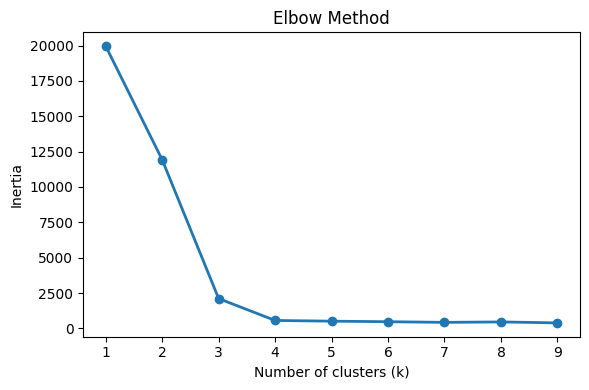

Converged in  : 2 iterations
Centroid shape: (4, 2)


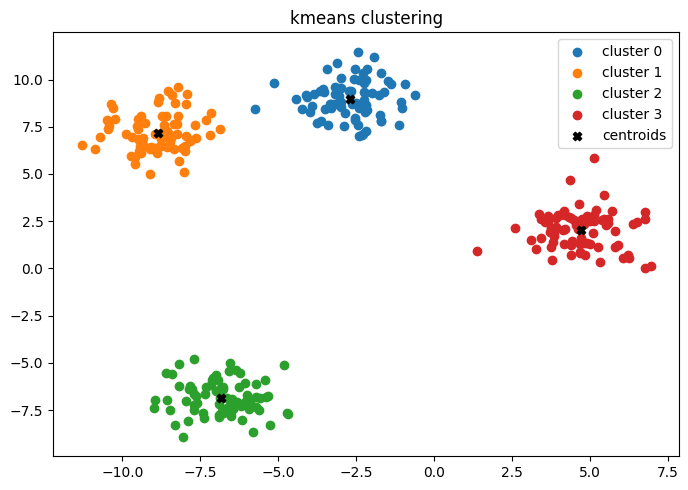


New point clusters: [3 3 0]


In [4]:
if __name__ == "__main__":
    from sklearn.datasets import make_blobs

    # ── 1. Generate synthetic data ──────────────────────────────────
    X, y_true = make_blobs(n_samples=300, centers=4,random_state=42)

    k_range, inertias = KMeans.elbow(X, k_range=range(1, 10), random_state=42)
    plot_elbow(k_range, inertias)

    # ── 3. Fit with optimal k ────────────────────────────────────────
    km = KMeans(k=4, random_state=42)
    km.fit(X)

    print(f"Converged in  : {km.n_iter_} iterations")
    print(f"Centroid shape: {km.centroids.shape}")

    plot_clusters(X, km.labels_, km.centroids)

    # ── 4. Predict on new points ─────────────────────────────────────
    new_points = np.array([[0, 0], [5, 5], [-3, 2]])
    print(f"\nNew point clusters: {km.predict(new_points)}")
